# Seminar: Visualisierung von Sport-Daten

In [2]:
import pandas as pd # um daten zu verarbeiten
import requests # ermöglicht das abrufen von webseiteninhalten
from bs4 import BeautifulSoup # zum auslesen und parsen von html-strukturen aus webseiten
import time # für zeitliche pausen
import difflib # ähnlich geschriebene strings zu vergleichen oder zuzuordnen

## Datenaufbereitung: Spieldaten und Elo Werte

In [3]:
# lädt den datensatz mit allen champions-league-spielen der saison 2024 im neuen format
df_newFormat = pd.read_csv(r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2024-UTC.csv")

In [4]:
# zeigt die ersten fünf zeilen des datensatzes
df_newFormat.head()

,Match Number,Round Number,Date,Location,Home Team,Away Team,Result
0,1,1,17/09/2024 16:45,Juventus Stadium,Juventus,PSV,3 - 1
1,2,1,17/09/2024 16:45,Stadion Wankdorf,Young Boys,Aston Villa,0 - 3
2,3,1,17/09/2024 19:00,Fußball Arena München,Bayern München,GNK Dinamo,9 - 2
3,4,1,17/09/2024 19:00,Stadio San Siro,Milan,Liverpool,1 - 3
4,5,1,17/09/2024 19:00,Estadio Santiago Bernabéu,Real Madrid,Stuttgart,3 - 1


In [5]:
# diese funktion zerlegt das ergebnis-feld in zwei ganze zahlen: tore heim und tore auswärts
def split_result(result):
    try:
        home, away = result.strip().split('-') # trennt das ergebnis bei "-" in zwei teile
        return int(home.strip()), int(away.strip()) # gibt heim- und auswärtstore als ganze zahlen zurück
    except:
        return None, None # falls etwas schiefgeht

# wendet die funktion auf jede zeile der spalte "Result" an und speichert heim- und auswärtstore in zwei neuen spalten
df_newFormat[['Home Goals', 'Away Goals']] = df_newFormat['Result'].apply(
    lambda x: pd.Series(split_result(x))
).astype('Int64') # stellt sicher, dass auch fehlende werte als integer behandelt werden können

In [6]:
# überblick über gesamten Datensatz
df_newFormat

,Match Number,Round Number,Date,Location,Home Team,Away Team,Result,Home Goals,Away Goals
0,1,1,17/09/2024 16:45,Juventus Stadium,Juventus,PSV,3 - 1,3,1
1,2,1,17/09/2024 16:45,Stadion Wankdorf,Young Boys,Aston Villa,0 - 3,0,3
2,3,1,17/09/2024 19:00,Fußball Arena München,Bayern München,GNK Dinamo,9 - 2,9,2
3,4,1,17/09/2024 19:00,Stadio San Siro,Milan,Liverpool,1 - 3,1,3
4,5,1,17/09/2024 19:00,Estadio Santiago Bernabéu,Real Madrid,Stuttgart,3 - 1,3,1
...,...,...,...,...,...,...,...,...,...
184,185,SF Game 1,29/04/2025 19:00,Arsenal Stadium,Arsenal,Paris,0 - 1,0,1
185,186,SF Game 1,30/04/2025 19:00,Estadi Olímpic Lluís Companys,Barcelona,Inter,3 - 3,3,3
186,187,SF Game 2,06/05/2025 19:00,Stadio San Siro,Inter,Barcelona,4 - 3,4,3
187,188,SF Game 2,07/05/2025 19:00,Parc des Princes,Paris,Arsenal,2 - 1,2,1


### Webscraping

In [ ]:
# ucl elo-rankings für die saison 2024/25 automatisch von clubelo.com abrufen

# import time
# import pandas as pd
# import requests
# from bs4 import BeautifulSoup

# # 1) champions-league-spiele aus csv-datei laden
# df = pd.read_csv("champions-league-2024-UTC.csv")  # CSV-Datei mit allen Spielen

# # datum in datetime-format umwandeln und zeilen nach datum sortieren
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
# df_sorted = df.sort_values(by="Date")

# # 2) wichtige stichtage für das abrufen der elo-tabellen bestimmen
# grp = df_sorted.groupby("Round Number")["Date"]

# # erstes und letztes datum je runde extrahieren
# first_per_round = grp.min()
# last_per_round  = grp.max()

# # alle stichtage in einer sortierten liste zusammenfassen
# anchor_dates = pd.concat([first_per_round, last_per_round]) \
#                  .sort_values() \
#                  .dt.normalize() \
#                  .unique()

# # ziel: auch das finale soll erfasst werden
# TARGET_END = pd.Timestamp("2025-05-31")

# # falls clubelo kein ranking exakt am finaltag hat: wöchentliche backup-daten erzeugen
# start_ext = (anchor_dates[-1] if len(anchor_dates) > 0 else df_sorted["Date"].min()).normalize()
# weekly_extra = pd.date_range(start_ext, TARGET_END, freq="7D")

# # vollständige liste aller abzurufenden datumswerte erstellen
# all_dates = (pd.Index(anchor_dates)
#              .append(weekly_extra)
#              .append(pd.Index([TARGET_END]))
#              .unique()
#              .sort_values())

# # datumswerte in string-format für die url-anfragen umwandeln
# date_list_for_urls = all_dates.strftime("%Y-%m-%d").tolist()
# print(date_list_for_urls[:5], "...", date_list_for_urls[-5:])


# # 3) clubelo-tabellen für jeden stichtag abrufen
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")

#     try:
#         # webseite abrufen
#         response = requests.get(url, headers=headers, timeout=20)
#         soup = BeautifulSoup(response.text, "html.parser")
#         # tabelle mit ranking finden
#         table = soup.find("table", class_="ranking")

#         # falls tabelle vorhanden: in dataframe umwandeln und speichern
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # datum zur tabelle hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None

#     except Exception as e:
#         # fehler beim abruf protokollieren und leeren eintrag speichern
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None  # <-- gleiche Einrückung wie print-Zeile

#     # kurze pause zwischen den anfragen, um die webseite nicht zu überlasten
#     time.sleep(5)

# # 4) alle erfolgreichen tabellen zusammenfassen und speichern
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# if all_tables:
#     # alle datentabellen zu einem dataframe zusammenfügen
#     df_combined = pd.concat(all_tables, ignore_index=True)
#     # daten als csv-datei speichern
#     df_combined.to_csv("ucl_elo_rankings_2024_2025.csv", index=False)
#     print("Tabellen gespeichert in 'ucl_elo_rankings_2024_2025.csv'")
# else:
#     print("Die Tabellen wurden nicht gefunden.")


In [7]:
# lädt eine csv-datei mit den elo-rankings der teams für die saison 2024/2025
df_newFormat_elo = pd.read_csv(r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\ucl_elo_rankings_2024_2025.csv")

In [8]:
# überblick über Elo-Ratings
df_newFormat_elo

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Man City,2061,NaN,2024-09-14,Pep Guardiola (since 2016-07-01),2024-09-17
1,2,2 Real Madrid,1993,NaN,2024-09-14,Carlo Ancelotti (since 2021-07-01),2024-09-17
2,3,3 Inter,1960,NaN,2024-09-15,Simone Inzaghi (since 2021-07-01),2024-09-17
3,4,4 Arsenal,1956,NaN,2024-09-15,Mikel Arteta (since 2019-12-22),2024-09-17
4,5,5 Leverkusen,1924,NaN,2024-09-14,Xabi Alonso (since 2022-10-05),2024-09-17
...,...,...,...,...,...,...,...
259,4,8 Bayern,1913,(+0.2),2025-04-12,Vincent Kompany (since 2024-07-01),2025-04-16
260,1,2 Arsenal,2010,NaN,2025-04-23,Mikel Arteta (since 2019-12-22),2025-04-29
261,2,3 Barcelona,1958,NaN,2025-04-22,Hansi Flick (since 2024-07-01),2025-04-29
262,3,5 Inter,1942,NaN,2025-04-27,Simone Inzaghi (since 2021-07-01),2025-04-29


In [9]:
# die Elo-Ratings als Excel-Datei speichern
df_newFormat_elo.to_excel("df_newFormat_elo.xlsx", index=False)

## Zusammenführung von Spieldaten und Elo Werten

In [10]:
# imports
import pandas as pd
import numpy as np
import re, unicodedata
from difflib import SequenceMatcher

# entfernt akzente aus einem string
def strip_accents(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', str(s)) if unicodedata.category(c) != 'Mn')

# vereinheitlicht und bereinigt einen teamnamen
def normalize_name(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"^\d+\s+", "", s)     # führende nummern weg
    s = strip_accents(s).lower()
    s = re.sub(r"[^\w\s-]", "", s)    # sonderzeichen weg
    s = re.sub(r"\s+", " ", s).strip()
    return s

# kleine hilfsfunktion zum sicheren spaltenfinden
def pick_col(df: pd.DataFrame, candidates: list, label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"spalte nicht gefunden für {label}. geprüft wurden: {candidates}")

# datumsspalten klug parsen
# nimmt iso-format yyyy-mm-dd wenn erkannt
# sonst fällt es auf dayfirst zurück
def parse_dates(series: pd.Series) -> pd.Series:
    sample = series.dropna().astype(str).head(20).tolist()
    iso_like = any(re.match(r"^\d{4}-\d{2}-\d{2}$", s) for s in sample)
    if iso_like:
        return pd.to_datetime(series, errors="coerce", format="%Y-%m-%d")
    else:
        return pd.to_datetime(series, errors="coerce", dayfirst=True)

# definiert, ab wann tokens als kurz gelten
SHORT_TOKEN_MAXLEN = 3
STOPWORDS = {"fc","cf","sc","ac","club","ud","cd","fk","sk","sv","ss"}

# zerlegt string in sinnvolle tokens ohne stopwörter
def token_set(s: str) -> set:
    return {t for t in s.split() if t and t not in STOPWORDS}

# bildet ein acronym aus den ersten buchstaben der tokens
def acronym(s: str) -> str:
    toks = [t for t in s.split() if t not in STOPWORDS]
    if len(toks) == 1 and len(toks[0]) <= 4:
        return toks[0]
    return "".join(t[0] for t in toks if t)

# berechnet eine ähnlichekeitsmetrik zwischen zwei strings
def sim_score(a: str, b: str) -> float:
    a_in_b = 1.0 if (a in b or b in a) else 0.0
    ta, tb = token_set(a), token_set(b)
    jacc = len(ta & tb) / (len(ta | tb) or 1)
    acr = 1.0 if (acronym(a) == acronym(b)) else 0.0
    diff = SequenceMatcher(None, a, b).ratio()
    return max(a_in_b, acr, diff, jacc) * 0.7 + (a_in_b + acr + diff + jacc) / 4 * 0.3

# erzeugt lockere namensvarianten zur robusteren zuordnung
def relaxed_variants(key: str):
    # original, ohne führendes kurzes token, ohne letztes kurzes token, nur mittlere tokens
    toks = key.split()
    yields = {key}
    if not toks:
        return list(yields)
    if len(toks[0]) <= SHORT_TOKEN_MAXLEN and len(toks) >= 2:
        yields.add(" ".join(toks[1:]))
    if len(toks[-1]) <= SHORT_TOKEN_MAXLEN and len(toks) >= 2:
        yields.add(" ".join(toks[:-1]))
    if len(toks) >= 3 and len(toks[0]) <= SHORT_TOKEN_MAXLEN and len(toks[-1]) <= SHORT_TOKEN_MAXLEN:
        yields.add(" ".join(toks[1:-1]))
    return list(yields)

# daten vorbereiten
matches = df_newFormat.copy()
elo = df_newFormat_elo.copy()

# spaltennamen im matchdatensatz robust finden
date_col = pick_col(matches, ["Date","date","Datum"], "datum")
home_col = pick_col(matches, ["Home Team","Home","home_team"], "heimteam")
away_col = pick_col(matches, ["Away Team","Away","away_team"], "auswärtsteam")

# datum parsen ohne verwirrende warnung
matches[date_col] = parse_dates(matches[date_col])

# spalten in elo datensatz robust finden
elo_date_col = pick_col(elo, ["Date","date","Ranking Date","As of","Updated","Datum"], "elo datum")
elo_val_col  = pick_col(elo, ["Elo","elo","ELO","Rating","rating"], "elo wert")
club_col     = pick_col(elo, ["Club","club","Team","team","Verein"], "clubname")

# elo datums und werte sauber typisieren
elo[elo_date_col] = parse_dates(elo[elo_date_col])
elo[elo_val_col]  = pd.to_numeric(elo[elo_val_col], errors="coerce")

# normierte klubnamen für den lookup erzeugen
elo_series = (
    elo[[elo_date_col, elo_val_col, club_col]]
      .rename(columns={elo_date_col: "elo_date", elo_val_col: "Elo", club_col: "Club"})
      .dropna(subset=["elo_date","Elo","Club"])
      .copy()
)
elo_series["club_key"] = elo_series["Club"].map(normalize_name)
elo_series = elo_series.sort_values(["club_key","elo_date"]).reset_index(drop=True)

# dictionary mit klub zu datumreihe und elo wert
elo_dict = {}
for key, grp in elo_series.groupby("club_key", sort=False):
    elo_dict[key] = (grp["elo_date"].to_numpy(), grp["Elo"].to_numpy())
elo_keys = set(elo_dict.keys())

# sucht je zeile den zuletzt bekannten elo wert des teams vor dem spieltag
def lookup_asof_for_rows(team_keys: pd.Series, dates: pd.Series) -> pd.Series:
    if not team_keys.index.equals(dates.index):
        dates = dates.reindex(team_keys.index)
    out = pd.Series(np.nan, index=team_keys.index, dtype=float)
    for t, idx in team_keys.groupby(team_keys).groups.items():
        if t not in elo_dict:
            continue
        ed, ev = elo_dict[t]
        if ed.size == 0:
            continue
        d = dates.loc[idx].to_numpy()
        pos = np.searchsorted(ed, d, side="right") - 1
        pos = np.where(pos < 0, 0, pos)  # nimmt zur not den frühesten elo
        out.loc[idx] = ev[pos]
    return out

# klubnamen im matchdatensatz normieren
matches["home_key"] = matches[home_col].map(normalize_name)
matches["away_key"] = matches[away_col].map(normalize_name)

# falls die zielspalten noch nicht existieren, lege sie an
if "Elo Home" not in matches.columns:
    matches["Elo Home"] = np.nan
if "Elo Away" not in matches.columns:
    matches["Elo Away"] = np.nan

# fehlende elo werte markieren
need_home = matches["Elo Home"].isna()
need_away = matches["Elo Away"].isna()

# keys sammeln, die im elo nachschlagewerk fehlen
missing_keys = set(matches.loc[need_home, "home_key"].dropna().unique()).union(
               set(matches.loc[need_away, "away_key"].dropna().unique()))
missing_keys = {k for k in missing_keys if k not in elo_keys}

# mapping erzeugen für unbekannte teams
map_update = {}
for k in sorted(missing_keys):
    best_cand, best_s = None, -1.0
    for v in relaxed_variants(k):
        subs = [c for c in elo_keys if v in c or c in v]
        if subs:
            cand, s = max(((c, len(c)) for c in subs), key=lambda x: x[1])
            s = 1.0
        else:
            cand, s = max(((c, sim_score(v, c)) for c in elo_keys), key=lambda x: x[1])
        if s > best_s:
            best_cand, best_s = cand, s
    if best_s >= 0.50:
        map_update[k] = best_cand

# mapping anwenden und elo werte auffüllen
if need_home.any():
    idx = matches.index[need_home]
    matches.loc[idx, "home_key"] = matches.loc[idx, "home_key"].replace(map_update)
    matches.loc[idx, "Elo Home"] = lookup_asof_for_rows(matches.loc[idx, "home_key"], matches[date_col])

if need_away.any():
    idx = matches.index[need_away]
    matches.loc[idx, "away_key"] = matches.loc[idx, "away_key"].replace(map_update)
    matches.loc[idx, "Elo Away"] = lookup_asof_for_rows(matches.loc[idx, "away_key"], matches[date_col])

# aufräumen
df_newFormat = matches.drop(columns=["home_key","away_key"], errors="ignore")

# zusammenfassung ausgeben
print("fehlende elo home:", int(df_newFormat["Elo Home"].isna().sum()),
      "| fehlende elo away:", int(df_newFormat["Elo Away"].isna().sum()))

# neue mappings zeigen
if map_update:
    print("neue automatische mappings auszug")
    for k, v in list(map_update.items())[:10]:
        print(f"'{k}' -> '{v}'")


fehlende elo home: 0 | fehlende elo away: 0
neue automatische mappings auszug
'atleti' -> 'atletico'
'b dortmund' -> 'dortmund'
'bayern munchen' -> 'bayern'
'club brugge' -> 'brugge'
'gnk dinamo' -> 'dinamo zagreb'
'leipzig' -> 'rb leipzig'
'paris' -> 'paris sg'
's bratislava' -> 'slovan bratislava'
'shakhtar' -> 'stuttgart'
'sporting cp' -> 'sporting'


In [11]:
# erstellt eine kopie des datensatzes, damit nichts im original überschrieben wird
matches2 = df_newFormat.copy()
# wandelt das datum in datetime-format um
matches2["Date"] = pd.to_datetime(matches2["Date"], errors="coerce", dayfirst=True)

# normiert die teamnamen
matches2["home_key"] = matches2["Home Team"].map(normalize_name)
matches2["away_key"] = matches2["Away Team"].map(normalize_name)

# markiert die zeilen, bei denen elo-werte noch fehlen
need_home = matches2["Elo Home"].isna()
need_away = matches2["Elo Away"].isna()

# hilfsfunktion zum automatischen zuordnen von teamnamen
# versucht für jeden unbekannten namen den ähnlichsten bekannten namen aus den elo-daten zu finden
def auto_map_missing(team_series: pd.Series, elo_keys: set, thresh: float = 0.55) -> dict:
    missing_keys = set(team_series[team_series.notna() & ~team_series.isin(elo_keys)].unique())
    mapping = {}
    for k in missing_keys:
        best_cand, best_s = None, -1.0
        for c in elo_keys:
            s = sim_score(k, c)
            if s > best_s:
                best_cand, best_s = c, s
        if best_s >= thresh:
            mapping[k] = best_cand
    return mapping

# versucht für fehlende home-elo-werte passende teamnamen zu finden
map_home = auto_map_missing(matches2.loc[need_home, "home_key"], set(elo_dict.keys()))
# das gleiche für away
map_away = auto_map_missing(matches2.loc[need_away, "away_key"], set(elo_dict.keys()))

# wenn home-mappings gefunden wurden, anwenden und elo-werte zuordnen
if map_home:
    idx = matches2.index[need_home]
    matches2.loc[idx, "home_key"] = matches2.loc[idx, "home_key"].replace(map_home)
    matches2.loc[idx, "Elo Home"] = lookup_asof_for_rows(matches2.loc[idx, "home_key"], matches2.loc[idx, "Date"])

# das gleiche für away
if map_away:
    idx = matches2.index[need_away]
    matches2.loc[idx, "away_key"] = matches2.loc[idx, "away_key"].replace(map_away)
    matches2.loc[idx, "Elo Away"] = lookup_asof_for_rows(matches2.loc[idx, "away_key"], matches2.loc[idx, "Date"])

# entfernt die hilfsspalten, damit der datensatz wieder sauber aussieht
df_newFormat = matches2.drop(columns=["home_key","away_key"], errors="ignore")

# zählt, wie viele elo-werte nach diesem schritt noch fehlen
miss_h = int(df_newFormat["Elo Home"].isna().sum())
miss_a = int(df_newFormat["Elo Away"].isna().sum())

# ausgabe der fehlenden werte
print("Nach Schritt 2 -> Fehlende Elo Home:", miss_h, "| Fehlende Elo Away:", miss_a)

# wenn noch werte fehlen, zeige beispiele
if miss_h or miss_a:
    print("\nBeispiele offener Fälle:")
    if miss_h:
        print(df_newFormat[df_newFormat["Elo Home"].isna()][["Home Team","Date"]].head(5))
    if miss_a:
        print(df_newFormat[df_newFormat["Elo Away"].isna()][["Away Team","Date"]].head(5))
        
    # wenn neue mappings gemacht wurden, zeige eine vorschau davon
    if map_home or map_away:
        print("\nAutomatische Mapping-Entscheidungen:")
        for k,v in list(map_home.items())[:10]: print(f"home: '{k}' -> '{v}'")
        for k,v in list(map_away.items())[:10]: print(f"away: '{k}' -> '{v}'")


Nach Schritt 2 -> Fehlende Elo Home: 0 | Fehlende Elo Away: 0


In [12]:
# entfernt home_clean & away_clean
df_newFormat = df_newFormat.drop(columns=["home_clean", "away_clean"], errors="ignore")

In [13]:
# überblick über Datensatz
df_newFormat

,Match Number,Round Number,Date,Location,Home Team,Away Team,Result,Home Goals,Away Goals,Elo Home,Elo Away
0,1,1,2024-09-17 16:45:00,Juventus Stadium,Juventus,PSV,3 - 1,3,1,1829.0,1799.0
1,2,1,2024-09-17 16:45:00,Stadion Wankdorf,Young Boys,Aston Villa,0 - 3,0,3,1553.0,1782.0
2,3,1,2024-09-17 19:00:00,Fußball Arena München,Bayern München,GNK Dinamo,9 - 2,9,2,1913.0,1570.0
3,4,1,2024-09-17 19:00:00,Stadio San Siro,Milan,Liverpool,1 - 3,1,3,1822.0,1903.0
4,5,1,2024-09-17 19:00:00,Estadio Santiago Bernabéu,Real Madrid,Stuttgart,3 - 1,3,1,1993.0,1800.0
...,...,...,...,...,...,...,...,...,...,...,...
184,185,SF Game 1,2025-04-29 19:00:00,Arsenal Stadium,Arsenal,Paris,0 - 1,0,1,2010.0,1935.0
185,186,SF Game 1,2025-04-30 19:00:00,Estadi Olímpic Lluís Companys,Barcelona,Inter,3 - 3,3,3,1958.0,1942.0
186,187,SF Game 2,2025-05-06 19:00:00,Stadio San Siro,Inter,Barcelona,4 - 3,4,3,1942.0,1958.0
187,188,SF Game 2,2025-05-07 19:00:00,Parc des Princes,Paris,Arsenal,2 - 1,2,1,1935.0,2010.0


In [14]:
# merkt sich den index der letzten zeile im datensatz
last_idx = df_newFormat.index[-1]

# definiert das neue ergebnis und die zugehörigen tore
new_result = "5 - 0"
home_goals = 5.0
away_goals = 0.0

# trägt das neue ergebnis in die letzte zeile ein
df_newFormat.at[last_idx, "Result"] = new_result
df_newFormat.at[last_idx, "Home Goals"] = home_goals
df_newFormat.at[last_idx, "Away Goals"] = away_goals

# zeigt die aktualisierte letzte zeile zur kontrolle
df_newFormat.loc[last_idx]


Match Number                      189
Round Number                    Final
Date              2025-05-31 19:00:00
Location        Fußball Arena München
Home Team                       Paris
Away Team                       Inter
Result                          5 - 0
Home Goals                          5
Away Goals                          0
Elo Home                       1935.0
Elo Away                       1942.0
Name: 188, dtype: object

## Finaler Datensatz für das neue Format

In [15]:
# überblick über Datensatz
df_newFormat

,Match Number,Round Number,Date,Location,Home Team,Away Team,Result,Home Goals,Away Goals,Elo Home,Elo Away
0,1,1,2024-09-17 16:45:00,Juventus Stadium,Juventus,PSV,3 - 1,3,1,1829.0,1799.0
1,2,1,2024-09-17 16:45:00,Stadion Wankdorf,Young Boys,Aston Villa,0 - 3,0,3,1553.0,1782.0
2,3,1,2024-09-17 19:00:00,Fußball Arena München,Bayern München,GNK Dinamo,9 - 2,9,2,1913.0,1570.0
3,4,1,2024-09-17 19:00:00,Stadio San Siro,Milan,Liverpool,1 - 3,1,3,1822.0,1903.0
4,5,1,2024-09-17 19:00:00,Estadio Santiago Bernabéu,Real Madrid,Stuttgart,3 - 1,3,1,1993.0,1800.0
...,...,...,...,...,...,...,...,...,...,...,...
184,185,SF Game 1,2025-04-29 19:00:00,Arsenal Stadium,Arsenal,Paris,0 - 1,0,1,2010.0,1935.0
185,186,SF Game 1,2025-04-30 19:00:00,Estadi Olímpic Lluís Companys,Barcelona,Inter,3 - 3,3,3,1958.0,1942.0
186,187,SF Game 2,2025-05-06 19:00:00,Stadio San Siro,Inter,Barcelona,4 - 3,4,3,1942.0,1958.0
187,188,SF Game 2,2025-05-07 19:00:00,Parc des Princes,Paris,Arsenal,2 - 1,2,1,1935.0,2010.0


## Annahme: Die Unterschiede in der Verteilung der Elo-Differenzen zwischen dem alten und dem neuen Format sind gering. daher können die im alten Format geschätzten Regressionskoeffizienten (Betas) auch für die simulationen im neuen format verwendet werden.

## Simulation des neuen Formats mit Monte-Carlo (10.000 Wiederholungen)

In [16]:
import numpy as np
import pandas as pd
import random
from collections import Counter

# definiert die poisson-regressionskoeffizienten für die erwarteten tore
BETA0, BETA_ELO, BETA_HOME = 0.2289, 0.0020, 0.2019

# definiert die 36 teilnehmenden teams mit topfzuordnung
pots_df = pd.DataFrame({
    "Team": [
        "Real Madrid", "Manchester City", "Bayern München", "Paris Saint-Germain",
        "Liverpool", "Inter", "Dortmund", "Leipzig", "Barcelona", "Leverkusen",
        "Atlético de Madrid", "Atalanta", "Juventus", "Benfica", "Arsenal",
        "Club Brugge", "Shakhtar Donetsk", "AC Milan", "Feyenoord", "Sporting CP",
        "PSV Eindhoven", "Dinamo Zagreb", "Salzburg", "Lille", "Crvena Zvezda",
        "Young Boys", "Celtic", "Slovan Bratislava", "Monaco", "Sparta Praha",
        "Aston Villa", "Bologna", "Girona", "Stuttgart", "Sturm Graz", "Brest"
    ],
    "Pot": ["Pot 1"] * 9 + ["Pot 2"] * 9 + ["Pot 3"] * 9 + ["Pot 4"] * 9
})

# definiert die elo-werte der teams
elo_dict = {
    "Real Madrid": 1993, "Manchester City": 2061, "Bayern München": 1913,
    "Paris Saint-Germain": 1899, "Liverpool": 1903, "Inter": 1960,
    "Dortmund": 1875, "Leipzig": 1855, "Barcelona": 1910, "Leverkusen": 1924,
    "Atlético de Madrid": 1843, "Atalanta": 1870, "Juventus": 1829,
    "Benfica": 1761, "Arsenal": 1956, "Club Brugge": 1712, "Shakhtar Donetsk": 1577,
    "AC Milan": 1822, "Feyenoord": 1741, "Sporting CP": 1838, "PSV Eindhoven": 1799,
    "Dinamo Zagreb": 1570, "Salzburg": 1674, "Lille": 1757, "Crvena Zvezda": 1568,
    "Young Boys": 1553, "Celtic": 1656, "Slovan Bratislava": 1446,
    "Monaco": 1777, "Sparta Praha": 1728, "Aston Villa": 1782, "Bologna": 1764,
    "Girona": 1789, "Stuttgart": 1800, "Sturm Graz": 1606, "Brest": 1681
}

# ordnet jedem team sein land zu
country_dict = {
    "Real Madrid": "ESP", "Manchester City": "ENG", "Bayern München": "GER",
    "Paris Saint-Germain": "FRA", "Liverpool": "ENG", "Inter": "ITA",
    "Dortmund": "GER", "Leipzig": "GER", "Barcelona": "ESP", "Leverkusen": "GER",
    "Atlético de Madrid": "ESP", "Atalanta": "ITA", "Juventus": "ITA",
    "Benfica": "POR", "Arsenal": "ENG", "Club Brugge": "BEL", "Shakhtar Donetsk": "UKR",
    "AC Milan": "ITA", "Feyenoord": "NED", "Sporting CP": "POR",
    "PSV Eindhoven": "NED", "Dinamo Zagreb": "CRO", "Salzburg": "AUT", "Lille": "FRA",
    "Crvena Zvezda": "SRB", "Young Boys": "SUI", "Celtic": "SCO", "Slovan Bratislava": "SVK",
    "Monaco": "FRA",  
    "Sparta Praha": "CZE", "Aston Villa": "ENG", "Bologna": "ITA",
    "Girona": "ESP", "Stuttgart": "GER", "Sturm Graz": "AUT", "Brest": "FRA"
}

# fügt zu jedem team den elo-wert und das land hinzu
pots_df["Elo"] = pots_df["Team"].map(elo_dict)
pots_df["Country"] = pots_df["Team"].map(country_dict)

# erstellt einen ausgewogenen spielplan, in dem jedes team 8 gegner bekommt
# jedes team spielt gegen 2 gegner aus jedem anderen topf (1x zuhause, 1x auswärts)
def build_fixtures_rotation(pots_df, seed=7):
    rng = random.Random(seed)
    pots = sorted(pots_df["Pot"].unique())

    # gruppiert teams nach topf und mischt sie zufällig
    teams_by_pot = {p: pots_df.loc[pots_df["Pot"]==p, "Team"].tolist() for p in pots}
    for lst in teams_by_pot.values():
        rng.shuffle(lst)  # random Reihenfolge je Topf

    fixtures = []
    
    # erstellt partien zwischen teams aus unterschiedlichen töpfen
    for i in range(len(pots)):
        for j in range(i+1, len(pots)):
            A, B = teams_by_pot[pots[i]], teams_by_pot[pots[j]]
            for k in range(9):
                fixtures.append((A[k], B[k]))                # team aus A zuhause
                fixtures.append((B[(k+1) % 9], A[k]))        # team aus B zuhause
                
    # erstellt partien innerhalb desselben topfe
    for p in pots:
        S = teams_by_pot[p]
        for k in range(9):
            fixtures.append((S[k], S[(k+1) % 9]))
    return pd.DataFrame(fixtures, columns=["Home","Away"])

# repariert partien, bei denen heim- und auswärtsteam aus dem gleichen land stammen
# versucht das problem durch gegnertausch innerhalb desselben pot-paares zu lösen
def repair_same_country(fixtures, pots_df, max_passes=80, seed=42):
    rng = random.Random(seed)

    # ordnet teams ihren ländern und töpfen zu
    team_country = pots_df.set_index("Team")["Country"].to_dict()
    team_pot = pots_df.set_index("Team")["Pot"].to_dict()
    f = fixtures.copy().reset_index(drop=True)
    f["HomePot"] = f["Home"].map(team_pot); f["AwayPot"] = f["Away"].map(team_pot)

    # erstellt eine menge mit allen aktuellen paarungen
    pairset = set((h,a) for h,a in zip(f["Home"], f["Away"]))
    # gruppiert partien nach pot-paaren
    potpair_to_idxs = {}
    for idx, row in f.iterrows():
        potpair_to_idxs.setdefault((row["HomePot"], row["AwayPot"]), []).append(idx)

    # funktion, die alle aktuellen konflikte (gleiches land) findet
    def conflicts():
        return [i for i,(h,a) in enumerate(zip(f["Home"], f["Away"])) if team_country[h]==team_country[a]]

    # wiederhole versuche, konflikte aufzulösen
    for _ in range(max_passes):
        confs = conflicts()
        if not confs: break # keine konflikte mehr
        rng.shuffle(confs); changed = False
        for i in confs:
            h, a = f.at[i,"Home"], f.at[i,"Away"]
            hp, ap = f.at[i,"HomePot"], f.at[i,"AwayPot"]
            idxs = potpair_to_idxs[(hp, ap)]; rng.shuffle(idxs)
            for j in idxs:
                if j==i: continue
                h2, b = f.at[j,"Home"], f.at[j,"Away"]
                # überspringe, wenn paarung doppelt vorkommt oder neuen konflikt erzeugt
                if (h,b) in pairset or (h2,a) in pairset: continue
                if team_country[h]==team_country[b] or team_country[h2]==team_country[a]: continue
                # swap durchführen
                f.at[i,"Away"], f.at[j,"Away"] = b, a
                pairset.discard((h,a)); pairset.discard((h2,b))
                pairset.add((h,b)); pairset.add((h2,a))
                changed = True
                break
        if not changed:
            # wenn kein einzelner swap hilft, mische die away-teams im pot-paar komplett neu
            for key, idxs in potpair_to_idxs.items():
                aways = f.loc[idxs,"Away"].tolist(); rng.shuffle(aways)
                for ii, idx in enumerate(idxs):
                    f.at[idx, "Away"] = aways[ii]
            pairset = set((h,a) for h,a in zip(f["Home"], f["Away"]))
    # prüft final, ob noch konflikte vorhanden sind
    bad = [i for i,(h,a) in enumerate(zip(f["Home"], f["Away"])) if team_country[h]==team_country[a]]
    return f[["Home","Away"]], (len(bad)==0)

# stellt sicher, dass jedes team höchstens zwei gegner aus demselben land hat
# nutzt gezielte 2-swaps oder 3er-tauschzyklen, um regelverletzungen zu beheben
def enforce_country_quota(fixtures, pots_df, max_passes=400, seed=99):
    rng = random.Random(seed)
    f = fixtures.copy().reset_index(drop=True)
    # hole land und topf je team
    team_country = pots_df.set_index("Team")["Country"].to_dict()
    team_pot = pots_df.set_index("Team")["Pot"].to_dict()
    f["HomePot"] = f["Home"].map(team_pot); f["AwayPot"] = f["Away"].map(team_pot)

    # gruppiert partien nach pot-paaren (für erlaubte tauschpartner)
    potpair_to_idxs = {}
    for idx, row in f.iterrows():
        potpair_to_idxs.setdefault((row["HomePot"], row["AwayPot"]), []).append(idx)

    # zählt wie oft ein team gegen welches land gespielt hat
    def build_counts():
        cc = {t: Counter() for t in pots_df["Team"]}
        for h,a in zip(f["Home"], f["Away"]):
            cc[h][team_country[a]] += 1
            cc[a][team_country[h]] += 1
        return cc

    counts = build_counts()

    # prüft, ob der tausch die länderverteilung gültig hält
    def ok_after_swap(updates):
        tmp = {t: counts[t].copy() for t in counts}
        for team, old_opp, new_opp in updates:
            tmp[team][team_country[old_opp]] -= 1
            tmp[team][team_country[new_opp]] += 1
        return all(all(v <= 2 for v in tmp[t].values()) for t in tmp)

    for _ in range(max_passes):
        # finde teams, die gegen ein land mehr als 2 mal gespielt haben
        viol = [(t, c) for t in counts for c, v in counts[t].items() if v > 2]
        if not viol: break
        rng.shuffle(viol)
        changed = False

        for t, c in viol:
            # sammelt alle spiele, in denen t gegen gegner aus land c spielt
            idx_cand = []
            for i,(h,a) in enumerate(zip(f["Home"], f["Away"])):
                if h==t and team_country[a]==c: idx_cand.append(i)
                elif a==t and team_country[h]==c: idx_cand.append(i)
            rng.shuffle(idx_cand)

            done=False
            # versuch: 2-team-swap innerhalb des pot-paares
            for i in idx_cand:
                h, a = f.at[i,"Home"], f.at[i,"Away"]
                hp, ap = f.at[i,"HomePot"], f.at[i,"AwayPot"]
                
                for j in potpair_to_idxs[(hp, ap)]:
                    if j==i: continue
                    h2, b = f.at[j,"Home"], f.at[j,"Away"]
                    # keine neuen länderkonflikte erlauben
                    if team_country[h]==team_country[b]: continue
                    if team_country[h2]==team_country[a]: continue
                    # prüfe, ob der swap erlaubt ist
                    updates = [(h, a, b), (h2, b, a), (a, h2, h), (b, h, h2)]
                    if not ok_after_swap(updates): continue
                    # tausch anwenden
                    f.at[i,"Away"], f.at[j,"Away"] = b, a
                    for team, old_opp, new_opp in updates:
                        counts[team][team_country[old_opp]] -= 1
                        counts[team][team_country[new_opp]] += 1
                    changed=True; done=True
                    break
                if done: break

            if changed: break

            # falls kein 2-swap hilft, versuche 3er-rotation
            if not changed:
                idxs = potpair_to_idxs[(hp, ap)][:]; rng.shuffle(idxs)
                for i in idx_cand:
                    for j in idxs:
                        if j==i: continue
                        for k in idxs:
                            if k==i or k==j: continue
                            h1,a1 = f.at[i,"Home"], f.at[i,"Away"]
                            h2,a2 = f.at[j,"Home"], f.at[j,"Away"]
                            h3,a3 = f.at[k,"Home"], f.at[k,"Away"]
                            # prüft, ob neue konflikte entstehen würden
                            if (team_country[h1]==team_country[a2] or
                                team_country[h2]==team_country[a3] or
                                team_country[h3]==team_country[a1]):
                                continue
                            updates = [
                                (h1, a1, a2),(h2, a2, a3),(h3, a3, a1),
                                (a1, h3, h1),(a2, h1, h2),(a3, h2, h3)
                            ]
                            if not ok_after_swap(updates): continue
                            # 3er-rotation anwenden
                            f.at[i,"Away"], f.at[j,"Away"], f.at[k,"Away"] = a2, a3, a1
                            for team, old_opp, new_opp in updates:
                                counts[team][team_country[old_opp]] -= 1
                                counts[team][team_country[new_opp]] += 1
                            changed=True
                            break
                        if changed: break
                    if changed: break
        # wenn nichts geändert wurde, mische away-teams innerhalb aller pot-paarungen zufällig neu
        if not changed:
            for key, idxs in potpair_to_idxs.items():
                aways = f.loc[idxs,"Away"].tolist(); rng.shuffle(aways)
                for ii, idx in enumerate(idxs):
                    f.at[idx, "Away"] = aways[ii]
            counts = build_counts()

    # prüft final, ob die quotenregel eingehalten wurde
    final_counts = build_counts()
    ok = all(all(v<=2 for v in final_counts[t].values()) for t in final_counts)
    return f[["Home","Away"]], ok

# kombiniert rotation, länderkonfliktbehandlung und quotenregel in einem robusten spielplan-generator
# bei fehlschlägen wird der gesamte prozess mit anderem seed neu gestartet (max_tries mal)
def build_fixtures_uefa_resilient(pots_df, seed=7, max_tries=300):
    teams = pots_df["Team"].tolist()
    team_pot = pots_df.set_index("Team")["Pot"].to_dict()
    allpots = sorted(pots_df["Pot"].unique())

    for attempt in range(max_tries):
        s = seed + 101*attempt

        # 1. erstelle initialen spielplan mit rotation
        rota = build_fixtures_rotation(pots_df, seed=s)
        # 2. behebe direkte länderkonflikte
        fixed1, ok1 = repair_same_country(rota, pots_df, seed=s+17)
        if not ok1: continue # versuch war ungültig, neu starten
        # 3. setze länder-quotenregel durch (max. 2 gegner pro land)
        fixed2, ok2 = enforce_country_quota(fixed1, pots_df, seed=s+29)
        if not ok2: continue

        # 4. prüfe, ob jedes team 4 heim- und 4 auswärtsspiele hat
        home_ct = Counter(fixed2["Home"]); away_ct = Counter(fixed2["Away"])
        if not all(home_ct[t]==4 and away_ct[t]==4 for t in teams):
            continue
        # 5. prüfe, ob jedes team genau 2 gegner aus jedem topf hat (inkl. eigener)
        tmp = fixed2.copy(); tmp["AwayPot"] = tmp["Away"].map(team_pot)
        ok_pots = True
        for t in teams:
            opp_pots = tmp.loc[tmp["Home"]==t,"AwayPot"].tolist() + \
                       tmp.loc[tmp["Away"]==t,"Home"].map(team_pot).tolist()
            cnt = Counter(opp_pots)
            if any(cnt[p] != 2 for p in allpots):
                ok_pots = False; break
        if not ok_pots: continue

        # wenn alle bedingungen erfüllt sind, spielplan zurückgeben
        return fixed2

    # wenn nach allen versuchen kein gültiger plan erzeugt wurde
    raise RuntimeError("keinen regelkonformen Spielplan (trotz Restarts).")

# entscheidet ein ausgeglichenes duell nach zwei spielen
# nutzt erst verlängerung als kleine zusätzliche poisson phase
# danach entscheidet ein elfmeter modell mit elo einfluss
def _decide_two_leg_tie(g1h, g1a, g2h, g2a, elo_home_leg2, elo_away_leg2,
                        beta0=BETA0, beta_elo=BETA_ELO, beta_home=BETA_HOME, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    # summiert die tore über beide spiele mit korrekter heim auswärts zuordnung
    total_home = g1h + g2a; total_away = g1a + g2h
    if total_home != total_away:
        return "home" if total_home > total_away else "away"
    # verlängerung mit kleineren erwartungswerten
    elo_diff = elo_home_leg2 - elo_away_leg2
    lam_h = np.exp(beta0 + beta_elo*elo_diff + beta_home) / 3.0
    lam_a = np.exp(beta0 - beta_elo*elo_diff) / 3.0
    et_h = rng.poisson(lam_h); et_a = rng.poisson(lam_a)
    if et_h != et_a:
        return "home" if et_h > et_a else "away"
    # elfmeterschießen mit elo einfluss
    p_home = 1 / (1 + np.exp(-0.004 * elo_diff))
    return "home" if rng.random() < p_home else "away"

# simuliert ein hin und rückspiel zwischen zwei teams
# nutzt poisson tore basierend auf elo differenz und heimvorteil
# entscheidet bei gleichstand über verlängerung und elfmeter
def simulate_two_leg_match(home, away, elo_map, rng=None,
                           beta0=BETA0, beta_elo=BETA_ELO, beta_home=BETA_HOME):
    rng = np.random.default_rng() if rng is None else rng
    # erstes spiel mit home als heimteam
    ediff = elo_map[home] - elo_map[away]
    lam1_h = min(np.exp(beta0 + beta_elo*ediff + beta_home), 10)
    lam1_a = min(np.exp(beta0 - beta_elo*ediff), 10)
    g1h = rng.poisson(lam1_h); g1a = rng.poisson(lam1_a)
    # zweites spiel mit away als heimteam
    ediff2 = -ediff
    lam2_h = min(np.exp(beta0 + beta_elo*ediff2 + beta_home), 10)
    lam2_a = min(np.exp(beta0 - beta_elo*ediff2), 10)
    g2h = rng.poisson(lam2_h); g2a = rng.poisson(lam2_a)
    # direkte entscheidung über aggregat
    if g1h + g2a > g1a + g2h:
        return home
    elif g1h + g2a < g1a + g2h:
        return away
    else:
        # tie break mit verlängerung und elfmetern
        res = _decide_two_leg_tie(g1h, g1a, g2h, g2a, elo_map[away], elo_map[home],
                                  beta0, beta_elo, beta_home, rng)
        return home if res == "home" else away

# simuliert ein zwei spiele duell in zufälliger reihenfolge
# das spiegelt realistische auslosungen mit wechselndem heimrecht wider
def simulate_two_leg_random_order(a, b, elo_map, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return simulate_two_leg_match(a, b, elo_map, rng) if rng.random()<0.5 else simulate_two_leg_match(b, a, elo_map, rng)

# simuliert ein einzelnes finale auf neutralem platz
# bei gleichstand gibt es eine kleine verlängerung und danach ein elo basiertes elfmeterschießen
def simulate_single_final(a, b, elo_map, rng=None, beta0=BETA0, beta_elo=BETA_ELO):
    rng = np.random.default_rng() if rng is None else rng
    ediff = elo_map[a] - elo_map[b]
    lam_a = np.exp(beta0 + beta_elo*ediff)   # neutral
    lam_b = np.exp(beta0 - beta_elo*ediff)
    ga = rng.poisson(lam_a); gb = rng.poisson(lam_b)
    if ga > gb: return a
    if gb > ga: return b
    # kurze verlängerung
    ga += rng.poisson(lam_a/3.0); gb += rng.poisson(lam_b/3.0)
    if ga > gb: return a
    if gb > ga: return b
    # elfmeter basierend auf elo differenz
    p_a = 1/(1 + np.exp(-0.004*(elo_map[a]-elo_map[b])))
    return a if rng.random() < p_a else b

# spielt die ligaphase komplett durch und erzeugt die tabelle
# berechnet tore, punkte und mehrere tie breaker
# ergänzt außerdem drei maße zur gegnerstärke
def simulate_league_phase_table(pots_df, seed=2025, fixtures=None):
    rng = np.random.default_rng(seed)
    # spielplan aus builder oder vorgegeben übernehmen
    if fixtures is None:
        fixtures = build_fixtures_uefa_resilient(pots_df, seed=seed)  # robuster Builder
    else:
        fixtures = fixtures.copy().reset_index(drop=True)

    # elo lookup vorbereiten
    elo_map = pots_df.set_index("Team")["Elo"].to_dict()
    # lambda werte für tore nach poisson modell
    fixtures["Elo_Diff"] = fixtures["Home"].map(elo_map) - fixtures["Away"].map(elo_map)
    fixtures["lambda_home"] = np.exp(BETA0 + BETA_ELO*fixtures["Elo_Diff"] + BETA_HOME).clip(upper=10)
    fixtures["lambda_away"] = np.exp(BETA0 - BETA_ELO*fixtures["Elo_Diff"]).clip(upper=10)
    # tore simulieren
    fixtures["Goals_Home"] = rng.poisson(fixtures["lambda_home"])
    fixtures["Goals_Away"] = rng.poisson(fixtures["lambda_away"])
    # punkte und siege markieren
    fixtures["Points_Home"] = np.where(fixtures["Goals_Home"] > fixtures["Goals_Away"], 3,
                                np.where(fixtures["Goals_Home"] == fixtures["Goals_Away"], 1, 0))
    fixtures["Points_Away"] = np.where(fixtures["Goals_Home"] < fixtures["Goals_Away"], 3,
                                np.where(fixtures["Goals_Home"] == fixtures["Goals_Away"], 1, 0))
    fixtures["Home_Win"] = (fixtures["Goals_Home"] > fixtures["Goals_Away"]).astype(int)
    fixtures["Away_Win"] = (fixtures["Goals_Away"] > fixtures["Goals_Home"]).astype(int)

    # heim und auswärts statistik zusammenbauen
    teams = pots_df["Team"].tolist()
    h_stats = fixtures.groupby("Home").agg({
        "Points_Home":"sum","Goals_Home":"sum","Goals_Away":"sum","Home_Win":"sum"
    }).rename(columns={"Points_Home":"Points","Goals_Home":"GF","Goals_Away":"GA","Home_Win":"Wins_H"}).reindex(teams, fill_value=0)
    a_stats = fixtures.groupby("Away").agg({
        "Points_Away":"sum","Goals_Away":"sum","Goals_Home":"sum","Away_Win":"sum"
    }).rename(columns={"Points_Away":"Points","Goals_Away":"GF","Goals_Home":"GA","Away_Win":"Wins_A"}).reindex(teams, fill_value=0)

    # gesamt tabelle
    table = h_stats.add(a_stats, fill_value=0)
    table["GD"] = table["GF"] - table["GA"]
    table["Wins"] = table["Wins_H"] + table["Wins_A"]
    table["AwayGoals"] = a_stats["GF"]
    table["AwayWins"] = a_stats["Wins_A"]

    # gegnerstärke berechnen
    opps_map = {t: [] for t in teams}
    for h,a in zip(fixtures["Home"], fixtures["Away"]):
        opps_map[h].append(a); opps_map[a].append(h)
    tbl_vals = table[["Points","GD","GF"]]
    opp_points = {t: float(tbl_vals.loc[opps_map[t], "Points"].sum()) for t in teams}
    opp_gd     = {t: float(tbl_vals.loc[opps_map[t], "GD"].sum())     for t in teams}
    opp_gf     = {t: float(tbl_vals.loc[opps_map[t], "GF"].sum())     for t in teams}
    table["Opp_Points"] = table.index.map(opp_points)
    table["Opp_GD"]     = table.index.map(opp_gd)
    table["Opp_GF"]     = table.index.map(opp_gf)

    # sortierung nach tie break reihenfolge
    table = table.copy()
    table["Team"] = table.index
    table = table.sort_values(
        ["Points","GD","GF","AwayGoals","Wins","AwayWins","Opp_Points","Opp_GD","Opp_GF"],
        ascending=False
    )
    table.reset_index(drop=True, inplace=True)
    table.insert(0, "Position", range(1, len(table)+1))
    return fixtures, table, elo_map

# spielt die knockout phase von playoff bis finale
# nutzt die sektionen logik zur verteilung der seeds und playoff sieger
def simulate_knockouts_from_table(table, elo_map, rng):
    pos_to_team = dict(zip(table["Position"], table["Team"]))

    # playoff paarungen 9 bis 24
    playoff_pairs = [(9,24),(10,23),(11,22),(12,21),(13,20),(14,19),(15,18),(16,17)]
    playoff_winners = []
    for s_pos, u_pos in playoff_pairs:
        s_team = pos_to_team[s_pos]
        u_team = pos_to_team[u_pos]
        playoff_winners.append(simulate_two_leg_match(u_team, s_team, elo_map, rng))

    # r16 sektionen
    sections = {
        "A": {"seeds": [pos_to_team[1], pos_to_team[2]], "winners": [playoff_winners[6], playoff_winners[7]]},
        "B": {"seeds": [pos_to_team[3], pos_to_team[4]], "winners": [playoff_winners[4], playoff_winners[5]]},
        "C": {"seeds": [pos_to_team[5], pos_to_team[6]], "winners": [playoff_winners[2], playoff_winners[3]]},
        "D": {"seeds": [pos_to_team[7], pos_to_team[8]], "winners": [playoff_winners[0], playoff_winners[1]]},
    }

    r16_winners = {}
    for key, sec in sections.items():
        seeds = sec["seeds"][:]; wins = sec["winners"][:]
        rng.shuffle(seeds); rng.shuffle(wins)
        w1 = simulate_two_leg_match(wins[0], seeds[0], elo_map, rng)  # erstes Spiel beim Playoff-Sieger
        w2 = simulate_two_leg_match(wins[1], seeds[1], elo_map, rng)
        r16_winners[key] = [w1, w2]

    # viertelfinale und halbfinale mit festem raster
    qf1_cands = r16_winners["A"] + r16_winners["D"]
    qf2_cands = r16_winners["B"] + r16_winners["C"]
    rng.shuffle(qf1_cands); rng.shuffle(qf2_cands)
    qf1_w1 = simulate_two_leg_random_order(qf1_cands[0], qf1_cands[1], elo_map, rng)
    qf1_w2 = simulate_two_leg_random_order(qf1_cands[2], qf1_cands[3], elo_map, rng)
    qf2_w1 = simulate_two_leg_random_order(qf2_cands[0], qf2_cands[1], elo_map, rng)
    qf2_w2 = simulate_two_leg_random_order(qf2_cands[2], qf2_cands[3], elo_map, rng)

    sf1 = simulate_two_leg_random_order(qf1_w1, qf1_w2, elo_map, rng)
    sf2 = simulate_two_leg_random_order(qf2_w1, qf2_w2, elo_map, rng)

    # finale auf neutralem platz
    champion = simulate_single_final(sf1, sf2, elo_map, rng)
    return champion

# wrapper für eine komplette simulation von liga und knockout
def simulate_tournament(pots_df, seed=1234, fixtures=None):
    fixtures_built, table, elo_map = simulate_league_phase_table(pots_df, seed=seed, fixtures=fixtures)
    rng = np.random.default_rng(seed)
    champion = simulate_knockouts_from_table(table, elo_map, rng)
    return champion

# baut den spielplan einmal und nutzt ihn für viele durchläufe
# das spart zeit und vermeidet zufallsfehler im builder bei jedem run
fixtures_once = build_fixtures_uefa_resilient(pots_df, seed=2025)

# führt n monte carlo durchläufe aus und zählt die titel
N = 10_000
results = [simulate_tournament(pots_df.copy(), seed=10_000 + i, fixtures=fixtures_once) for i in range(N)]
# fasst die titel zusammen und sortiert absteigend
df_results = pd.DataFrame(Counter(results).items(), columns=["Team", "Titles_Won"])\
             .sort_values("Titles_Won", ascending=False).reset_index(drop=True)
# zeigt die verteilung der titelgewinne
print(df_results)


                   Team  Titles_Won
0       Manchester City        3115
1           Real Madrid        1504
2                 Inter         930
3               Arsenal         917
4            Leverkusen         619
5             Liverpool         460
6        Bayern München         455
7             Barcelona         423
8   Paris Saint-Germain         367
9              Dortmund         247
10              Leipzig         185
11             Atalanta         178
12             AC Milan         108
13             Juventus         107
14          Sporting CP          93
15   Atlético de Madrid          91
16        PSV Eindhoven          35
17               Girona          33
18            Stuttgart          33
19          Aston Villa          29
20               Monaco          22
21              Bologna          19
22            Feyenoord          12
23                Lille           9
24              Benfica           8
25         Sparta Praha           1


## Visualisierungen 

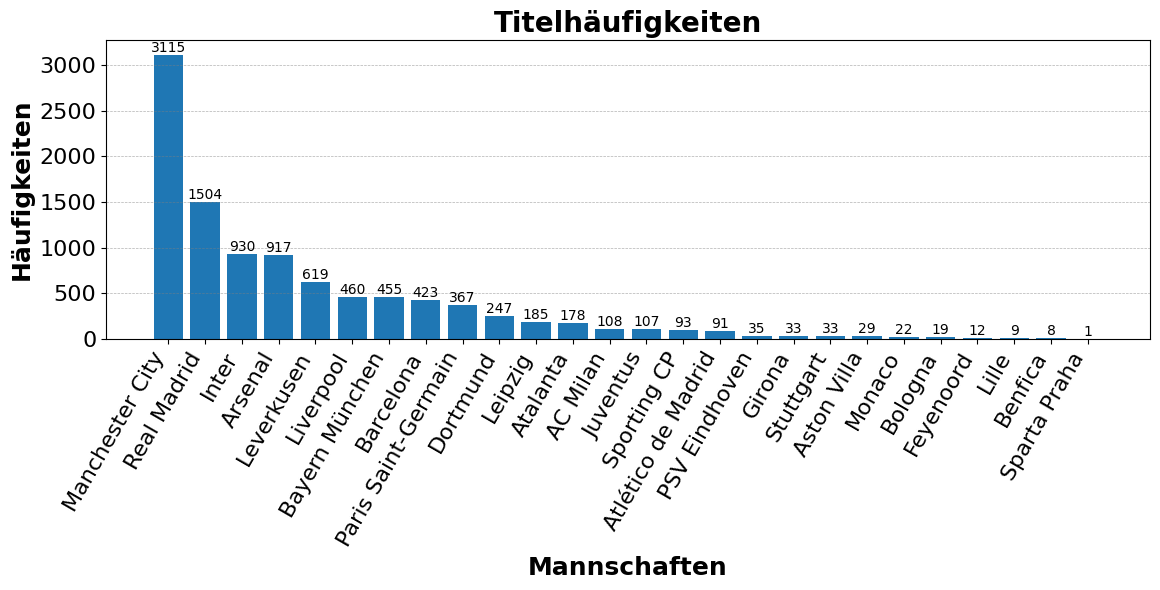

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# versuche, das ergebnis der simulation zu laden
# falls nicht vorhanden, werden die Ergebnisse manuell eingetragen
try:
    df_plot = df_results.copy()
except NameError:
    data = [
        ("Manchester City", 3115), ("Real Madrid", 1504), ("Inter", 930), ("Arsenal", 917),
        ("Leverkusen", 619), ("Liverpool", 460), ("Bayern München", 455), ("Barcelona", 423),
        ("Paris Saint-Germain", 367), ("Dortmund", 247), ("Leipzig", 185), ("Atalanta", 178),
        ("AC Milan", 108), ("Juventus", 107), ("Sporting CP", 93), ("Atlético de Madrid", 91),
        ("PSV Eindhoven", 35), ("Girona", 33), ("Stuttgart", 33), ("Aston Villa", 29),
        ("Monaco", 22), ("Bologna", 19), ("Feyenoord", 12), ("Lille", 9), ("Benfica", 8),
        ("Sparta Praha", 1),
    ]
    df_plot = pd.DataFrame(data, columns=["Team", "Titles_Won"])

# sortiert teams absteigend nach anzahl der gewonnenen titel
df_plot = df_plot.sort_values("Titles_Won", ascending=False)

# erstellt balkendiagramm zur visualisierung der titelverteilung
plt.figure(figsize=(max(10, 0.45*len(df_plot)), 6))
bars = plt.bar(df_plot["Team"], df_plot["Titles_Won"])

# horizontale linien 
for y in range(500, 3500, 500):
    plt.axhline(y=y, color="gray", linestyle="--", linewidth=0.5, alpha=0.6)

# zeigt absolute werte oberhalb der balken
for b, val in zip(bars, df_plot["Titles_Won"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(val)}",
             ha="center", va="bottom", fontsize=10)

# achsenbeschriftung und titel 
plt.xlabel("Mannschaften", fontweight='bold', fontsize=18)
plt.ylabel("Häufigkeiten", fontweight='bold', fontsize=18)
plt.title("Titelhäufigkeiten", fontweight='bold', fontsize=20)
plt.xticks(rotation=60, ha="right", fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()


# speichert die grafik als png und pdf
outdir = r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\Abbildungen"
os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, "absolute_titelhäufigkeiten.pdf"),
            bbox_inches="tight")

# zeigt die grafik an
plt.show()

In [18]:
from collections import Counter
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# erstellt einmal den spielplan (fixiert für alle simulationen)
fixtures_once = build_fixtures_uefa_resilient(pots_df, seed=2025)

# simuliert einen vollständigen turnierdurchlauf
# gibt für jede runde die teams zurück, die es erreicht haben
def simulate_one_run(pots_df, seed, fixtures):
    # liga Phase
    _, table, elo_map = simulate_league_phase_table(pots_df, seed=seed, fixtures=fixtures)
    rng = np.random.default_rng(seed)

    pos_to_team = dict(zip(table["Position"], table["Team"]))

   # playoff-paarungen: platz 9–24 (rückspiel bei seeds 9–16)
    playoff_pairs = [(9,24),(10,23),(11,22),(12,21),(13,20),(14,19),(15,18),(16,17)]
    playoff_winners = [simulate_two_leg_match(pos_to_team[u], pos_to_team[s], elo_map, rng)
                       for s,u in playoff_pairs]

    # achtelfinale (r16): seeds + playoff-sieger nach sektionen
    sections = {
        "A": {"seeds":[pos_to_team[1], pos_to_team[2]], "wins":[playoff_winners[6], playoff_winners[7]]},
        "B": {"seeds":[pos_to_team[3], pos_to_team[4]], "wins":[playoff_winners[4], playoff_winners[5]]},
        "C": {"seeds":[pos_to_team[5], pos_to_team[6]], "wins":[playoff_winners[2], playoff_winners[3]]},
        "D": {"seeds":[pos_to_team[7], pos_to_team[8]], "wins":[playoff_winners[0], playoff_winners[1]]},
    }

    # reams, die die achtelfinal erreichen 
    r16_set = set([pos_to_team[p] for p in range(1,9)] + playoff_winners)

    # achtelfinal-duelle simulieren
    r16_winners_all = []
    for sec in sections.values():
        seeds = sec["seeds"][:]; wins = sec["wins"][:]
        rng.shuffle(seeds); rng.shuffle(wins)
        r16_winners_all.append(simulate_two_leg_match(wins[0], seeds[0], elo_map, rng))
        r16_winners_all.append(simulate_two_leg_match(wins[1], seeds[1], elo_map, rng))
    qf_set = set(r16_winners_all)

    # viertelfinale nach sektionen a+d und b+c
    qf1_cands = r16_winners_all[0:2] + r16_winners_all[6:8]
    qf2_cands = r16_winners_all[2:4] + r16_winners_all[4:6]
    rng.shuffle(qf1_cands); rng.shuffle(qf2_cands)
    qf1_w1 = simulate_two_leg_random_order(qf1_cands[0], qf1_cands[1], elo_map, rng)
    qf1_w2 = simulate_two_leg_random_order(qf1_cands[2], qf1_cands[3], elo_map, rng)
    qf2_w1 = simulate_two_leg_random_order(qf2_cands[0], qf2_cands[1], elo_map, rng)
    qf2_w2 = simulate_two_leg_random_order(qf2_cands[2], qf2_cands[3], elo_map, rng)
    sf_set = {qf1_w1, qf1_w2, qf2_w1, qf2_w2}

    # halbfinale und finale
    sf1 = simulate_two_leg_random_order(qf1_w1, qf1_w2, elo_map, rng)
    sf2 = simulate_two_leg_random_order(qf2_w1, qf2_w2, elo_map, rng)
    final_set = {sf1, sf2}
    champion = simulate_single_final(sf1, sf2, elo_map, rng)
    return r16_set, qf_set, sf_set, final_set, champion, elo_map

# führt n durchläufe der simulation durch und zählt, wie oft jedes team eine runde erreicht hat
N = 10_000
teams = pots_df["Team"].tolist()
stage_counts = {k: Counter() for k in ["R16","QF","SF","Final","Champion"]}
elo_map_any = None # wird aus einer beliebigen simulation übernommen

for i in range(N):
    r16, qf, sf, fin, champ, elo_map_any = simulate_one_run(pots_df, seed=50_000+i, fixtures=fixtures_once)
    for t in r16:  stage_counts["R16"][t] += 1
    for t in qf:   stage_counts["QF"][t]  += 1
    for t in sf:   stage_counts["SF"][t]  += 1
    for t in fin:  stage_counts["Final"][t]+= 1
    stage_counts["Champion"][champ] += 1

# erstellt eine tabelle mit den wahrscheinlichkeiten pro team und phase
df = pd.DataFrame({
    "Team": teams,
    "Elo": [elo_map_any[t] for t in teams],
    "Achtelfinale": [stage_counts["R16"][t]/N for t in teams],
    "Viertelfinale": [stage_counts["QF"][t]/N for t in teams],
    "Halbfinale": [stage_counts["SF"][t]/N for t in teams],
    "Finale": [stage_counts["Final"][t]/N for t in teams],
    "Turniersieg": [stage_counts["Champion"][t]/N for t in teams],
}).sort_values(["Elo","Team"], ascending=[False, True]).reset_index(drop=True)

# gruppiert die spalten in multiindex für die heatmap-ansicht
df.columns = pd.MultiIndex.from_tuples([
    ("Teamstärke", "Team"),
    ("Teamstärke", "Elo"),
    ("Wahrscheinlichkeit für Erreichen der K.-o.-Phase", "Achtelfinale"),
    ("Wahrscheinlichkeit für Erreichen der K.-o.-Phase", "Viertelfinale"),
    ("Wahrscheinlichkeit für Erreichen der K.-o.-Phase", "Halbfinale"),
    ("Wahrscheinlichkeit für Erreichen der K.-o.-Phase", "Finale"),
    ("Wahrscheinlichkeit für Erreichen der K.-o.-Phase", "Turniersieg"),
])

# erstellt eine grüne heatmap zur visualisierung der wahrscheinlichkeiten
probability_cols = df.columns[df.columns.get_level_values(0)=="Wahrscheinlichkeit für Erreichen der K.-o.-Phase"]

# colormap von hellgrün (niedrig) bis dunkelgrün (hoch)
from matplotlib.colors import LinearSegmentedColormap
ucl_green = LinearSegmentedColormap.from_list(
    "ucl_green", ["#f0fff4", "#bbf7d0", "#4ade80", "#16a34a", "#166534"]
)

# "<1%" darstellung bei sehr kleinen werten
def lt1_formatter(x):
    try:
        return "<1%" if float(x) < 0.005 else f"{x:.0%}"
    except Exception:
        return x

# definiert, wie jede spalte formatiert werden soll
fmt_map = {col: lt1_formatter for col in probability_cols}
fmt_map[("Teamstärke","Elo")] = "{:.0f}"

# erstellt den styler mit heatmap und formatierung
styler = (
    df.style
      .format(fmt_map)
      .background_gradient(cmap=ucl_green, subset=probability_cols, vmin=0, vmax=1)
      .set_table_styles([
          {"selector":"th.col_heading.level0","props":[("font-weight","700"),("text-align","center")]},
          {"selector":"th.col_heading.level1","props":[("text-align","center")]},
      ])
)

styler



In [19]:
html_path = r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\Abbildungen\chances_heatmap_table.html"
styler.to_html(buf=html_path)
print("HTML gespeichert unter:", html_path)


HTML gespeichert unter: C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\Abbildungen\chances_heatmap_table.html


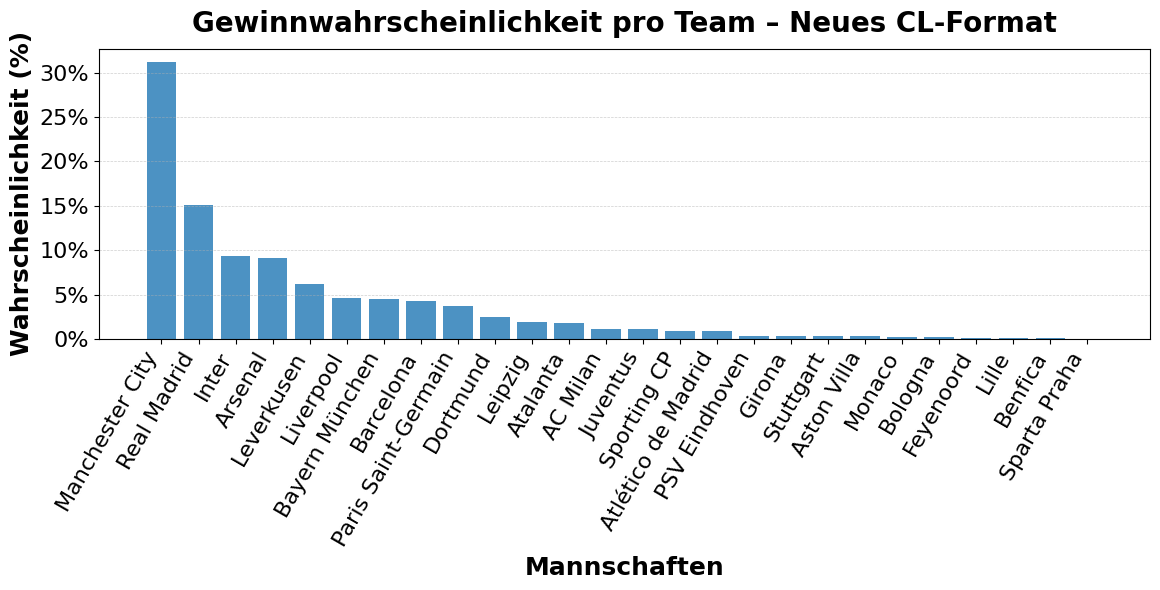

Gespeichert unter: C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\Abbildungen\gewinnwahrscheinlichkeit_neues_format.pdf


In [20]:
# plot: gewinnwahrscheinlichkeit pro team im neuen champions-league-format
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# erstelle eine kopie des ergebnisses und berechne prozentuale titelwahrscheinlichkeit
prob = df_results.copy()
prob["WinProb"] = prob["Titles_Won"] / N  # anteil der durchläufe, in denen das team siegte

# erzeuge ein balkendiagramm zur visualisierung
fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(prob)), 6))

# zeichne die balken mit prozentualer gewinnwahrscheinlichkeit
bars = ax.bar(prob["Team"], prob["WinProb"] * 100, color="#1f77b4", alpha=0.8)
plt.xticks(rotation=60, ha="right", fontsize=16)

# achsentitel und diagrammtitel setzen
ax.set_title("Gewinnwahrscheinlichkeit pro Team – Neues CL-Format", pad=12, fontweight='bold', fontsize=20)
ax.set_xlabel("Mannschaften", fontweight='bold', fontsize=18)
ax.set_ylabel("Wahrscheinlichkeit (%)", fontweight='bold', fontsize=18)

# achsenbeschriftung als prozent anzeigen
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# horizontale linien für bessere lesbarkeit
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
plt.xticks(rotation=60, ha="right", fontsize=16)
plt.yticks(fontsize=16)

# layout optimieren
plt.tight_layout()

# plot anzeigen
plt.show()

from pathlib import Path

# definiere zielordner und dateinamen
from pathlib import Path
out_dir = Path(r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\Abbildungen")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "gewinnwahrscheinlichkeit_neues_format.pdf"
fig.savefig(out_dir / "gewinnwahrscheinlichkeit_neues_format.pdf", bbox_inches="tight")
print("Gespeichert unter:", out_path)

